# Задание №8. Построение нейронной сети для выявления спама (классификация текстовых сообщений с помощью LSTM)


**Выполнил:** Асламин В.В.


**Группа:** МОм-24-1


**Дата:** 2026


**Ссылка на репозиторий:** https://github.com/mystic-solis/spam-detector-lstm

---

## 1. Введение


**Цель работы:** построить и обучить модель для классификации текстовых сообщений на спам и не-спам с использованием рекуррентных нейронных сетей (LSTM).


**Задачи:**
- Подготовить размеченный корпус SMS-сообщений
- Построить модель LSTM для бинарной классификации
- Обучить модель и оценить её качество
- Реализовать функцию предсказания для новых сообщений
- Сохранить модель и загрузить её из репозитория

## 2. Теоретическая часть

### 2.1. Задача выявления спама

Спам — это нежелательные сообщения, часто рассылаемые в больших объёмах. Автоматическое определение спама позволяет фильтровать входящие сообщения, повышая безопасность и удобство пользователей. Задача представляет собой **бинарную классификацию**: сообщение относится к одному из двух классов — спам (`spam`) или не-спам (`ham`).

### 2.2. Корпус данных

Для обучения необходим размеченный корпус, содержащий примеры сообщений с метками. Наиболее популярный датасет — **SMS Spam Collection** (UCI Machine Learning Repository), который содержит около 5 500 SMS с пометками «spam» и «ham».

### 2.3. Токенизация (Tokenization)

Процесс разбиения текста на минимальные единицы — **токены** (слова, знаки препинания). Для токенизации используем `Tokenizer` из Keras, который преобразует текст в последовательность целочисленных индексов.

### 2.4. Эмбеддинги (Embeddings)

Слой **Embedding** преобразует индексы токенов в плотные векторы фиксированной размерности. Эти векторы обучаются вместе с моделью и позволяют улавливать семантические и синтаксические сходства между словами.

### 2.5. Рекуррентные нейронные сети (RNN, LSTM)

RNN — класс сетей, способных обрабатывать последовательности произвольной длины благодаря внутренней памяти. **LSTM (Long Short-Term Memory)** — разновидность RNN, которая эффективно обучается на длинных последовательностях, избегая проблемы затухания градиента. В задаче выявления спама LSTM учитывает контекст и последовательность слов, что позволяет выявлять характерные спамерские фразы.

### 2.6. Метрики качества

Для бинарной классификации используют:
- **Accuracy** — доля правильных ответов.
- **Precision (точность)** — доля истинно-положительных среди всех предсказанных положительных.
- **Recall (полнота)** — доля найденных положительных примеров.
- **F1-score** — гармоническое среднее precision и recall.
- **AUC-ROC** — площадь под ROC-кривой.

## 3. Описание данных

### 3.1. Источник данных

В данной работе используется файл `spam_data.csv`, содержащий тексты SMS-сообщений и метки (spam/ham).

In [16]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pickle
import requests
import io
import os
from pathlib import Path
import random


print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


In [17]:

# Если загрузка из репозитория недоступна, используем локальный файл
data = Path('./data')
data.mkdir(exist_ok=True)
data_path = data / 'spam_data.csv'
if data_path.exists():
    df = pd.read_csv(data_path, encoding='utf-8')
else:
    # Создаём синтетический датасет для демонстрации
    print("Создание синтетического датасета...")
    ham_templates = [
        "Привет, как дела?", "Встреча завтра в 10.", "Спасибо за информацию!",
        "Позвони мне позже.", "Скинь фотографии с отпуска.",
        "Как дела? Что нового?", "До встречи!", "Хорошего дня!",
        "Сможешь перезвонить?", "Я дома, когда будешь?"
    ]
    spam_templates = [
        "Вы выиграли миллион! Перейдите по ссылке.",
        "Срочно! Ваш аккаунт заблокирован.",
        "Получите скидку 50% сегодня.",
        "Заработай лёгкие деньги!",
        "Пришлите смс на номер 1234 для активации.",
        "Поздравляем! Вы победили в лотерее!",
        "Ваш выигрыш ждёт вас!",
        "Подтвердите ваш аккаунт сейчас!",
        "Бесплатный iPhone! Не упустите шанс!",
        "Срочное сообщение! Действуйте немедленно!"
    ]

    data = []
    for _ in range(1000):
        data.append([random.choice(ham_templates), "ham"])
    for _ in range(500):
        data.append([random.choice(spam_templates), "spam"])

    random.shuffle(data)
    df = pd.DataFrame(data, columns=["message", "label"])
    df.to_csv("./data/spam_data.csv", index=False)
    print("Синтетический датасет создан и сохранён в data/spam_data.csv")

print("Данные загружены")
print(f"Загружено сообщений: {len(df)}")

print("Первые 5 строк:")
df.head()

Данные загружены
Загружено сообщений: 1500
Первые 5 строк:


,message,label
0,"Я дома, когда будешь?",ham
1,Позвони мне позже.,ham
2,Бесплатный iPhone! Не упустите шанс!,spam
3,До встречи!,ham
4,Спасибо за информацию!,ham


### 3.2. Статистика данных

In [18]:
# Статистика по данным
print("=" * 50)
print("СТАТИСТИКА ДАННЫХ")
print("=" * 50)

# Распределение классов
print("\nРаспределение классов:")
class_counts = df['label'].value_counts()
print(class_counts)

# Процентное распределение
print("\nПроцентное распределение:")
print(df['label'].value_counts(normalize=True).round(3) * 100)

# Средняя длина сообщения
df['text_length'] = df['message'].apply(lambda x: len(str(x).split()))
print(f"\nСредняя длина сообщения (в словах): {df['text_length'].mean():.2f}")
print(f"Минимальная длина: {df['text_length'].min()}")
print(f"Максимальная длина: {df['text_length'].max()}")

СТАТИСТИКА ДАННЫХ

Распределение классов:
label
ham     1000
spam     500
Name: count, dtype: int64

Процентное распределение:
label
ham     66.7
spam    33.3
Name: proportion, dtype: float64

Средняя длина сообщения (в словах): 3.57
Минимальная длина: 2
Максимальная длина: 7


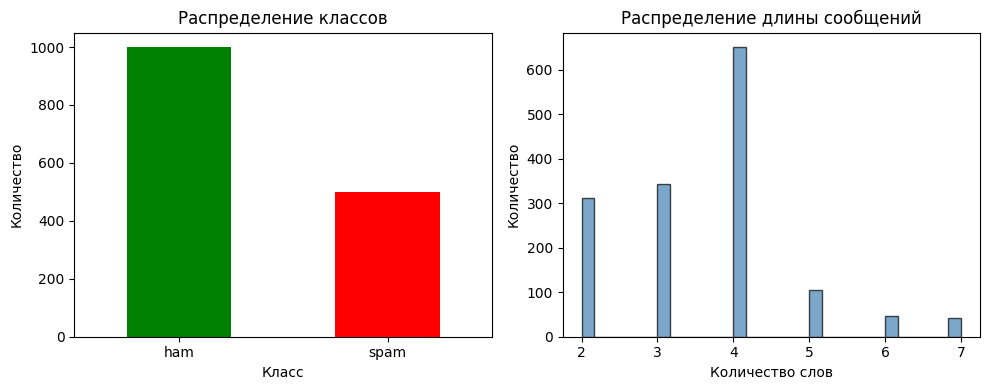

In [19]:
# Визуализация распределения классов
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
class_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.hist(df['text_length'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Распределение длины сообщений')
plt.xlabel('Количество слов')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

## 4. Подготовка данных

In [26]:
# Функция для очистки текста
def clean_text(text):
    text = str(text).lower()
    return text

df['clean_message'] = df['message'].apply(clean_text)

print("Текст очищен")

# Параметры токенизации
VOCAB_SIZE = 10000  # максимальный размер словаря
MAX_LENGTH = 20    # максимальная длина текста (в словах)

# Токенизация
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_message'])

sequences = tokenizer.texts_to_sequences(df['clean_message'])
X = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')


# Кодирование меток (spam → 1, ham → 0)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])
num_classes = 1  # бинарная классификация


print(f"Классы: {label_encoder.classes_}")
print(f"Число классов: {num_classes + 1}")
print(f"Форма X: {X.shape}")
print(f"Форма y: {y.shape}")

Текст очищен
Классы: ['ham' 'spam']
Число классов: 2
Форма X: (1500, 20)
Форма y: (1500,)


In [27]:
# Разделение на train/test (80/20) со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


print(f"Обучающих примеров: {len(X_train)}")
print(f"Тестовых примеров: {len(X_test)}")

print("\nРаспределение классов в обучающей выборке:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {label_encoder.classes_[cls]}: {cnt}")

Обучающих примеров: 1200
Тестовых примеров: 300

Распределение классов в обучающей выборке:
  ham: 800
  spam: 400


## 5. Построение модели

In [28]:
# Параметры модели
EMBEDDING_DIM = 128
LSTM_UNITS = 64

# Построение модели LSTM
model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LENGTH),
    LSTM(LSTM_UNITS, dropout=0.2),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

r:\projects\homework\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Обучение модели

In [29]:
# Early stopping для предотвращения переобучения
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Фиксация времени обучения
print("Начало обучения...")
start_time = time.time()

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"\nОбучение завершено!")
print(f"Время обучения: {training_time:.2f} секунд ({(training_time/60):.2f} минут)")

Начало обучения...
Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6698 - loss: 0.6130 - val_accuracy: 0.6250 - val_loss: 0.5413
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9604 - loss: 0.1170 - val_accuracy: 1.0000 - val_loss: 0.0115
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 7.0365e-04
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.8550e-04 - val_accuracy: 1.0000 - val_loss: 5.2789e-04
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 6.0153e-04 - val_accuracy: 1.0000 - val_loss: 4.0918e-04
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 5

### 6.1. Визуализация процесса обучения

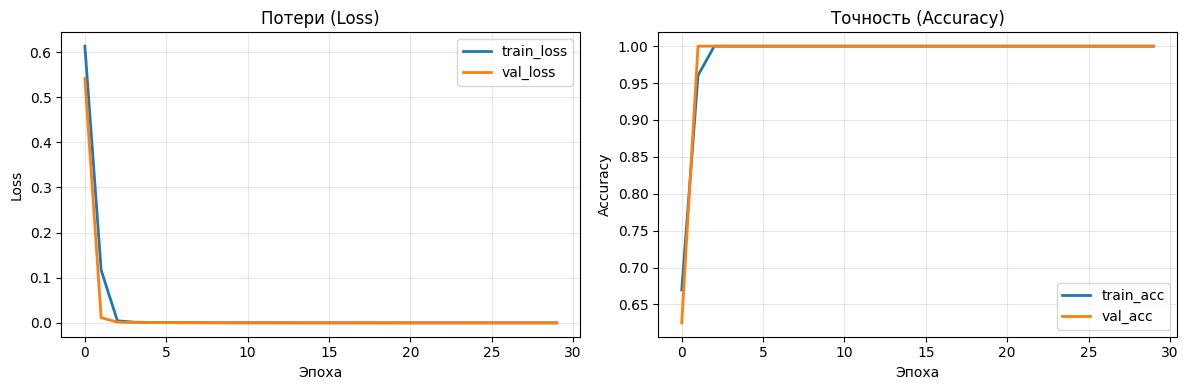

In [30]:
# Графики потерь и точности
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss', linewidth=2)
plt.plot(history.history['val_loss'], label='val_loss', linewidth=2)
plt.legend()
plt.title('Потери (Loss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_acc', linewidth=2)
plt.plot(history.history['val_accuracy'], label='val_acc', linewidth=2)
plt.legend()
plt.title('Точность (Accuracy)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Оценка качества модели

In [31]:
# Предсказания на тестовой выборке
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Метрики
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ")
print("=" * 60)

print(f"\nAccuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
ОЦЕНКА КАЧЕСТВА МОДЕЛИ

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Classification Report:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       200
        spam       1.00      1.00      1.00       100

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



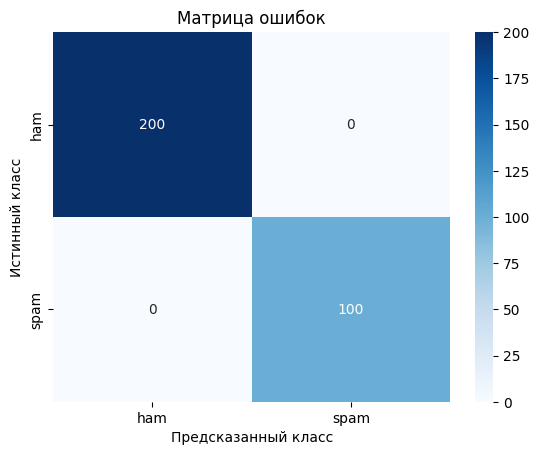

In [32]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

## 8. Функция предсказания

In [33]:
# Функция предсказания
def predict_spam(text):
    """
    Функция для предсказания класса SMS-сообщения
    
    Args:
        text: текст сообщения
    
    Returns:
        tuple: (класс, вероятность спама)
    """
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
    prob = model.predict(padded, verbose=0)[0][0]
    pred_class = (prob > 0.5).astype(int)
    return label_encoder.inverse_transform([pred_class])[0], prob


# Тестирование функции на примерах
test_messages = [
    "Поздравляем! Вы выиграли айфон. Перейдите по ссылке: http://bit.ly/...",
    "Встреча переносится на среду, извините за неудобства.",
    "Ваш аккаунт будет заблокирован, подтвердите данные немедленно.",
    "Привет! Как дела?",
    "Получите скидку 50% на все товары! Только сегодня!"
]

print("Тестирование функции предсказания:")
print("=" * 60)
for msg in test_messages:
    label, prob = predict_spam(msg)
    print(f"Сообщение: {msg}")
    print(f"Класс: {label}, вероятность спама: {prob:.4f}\n")

Тестирование функции предсказания:
Сообщение: Поздравляем! Вы выиграли айфон. Перейдите по ссылке: http://bit.ly/...
Класс: spam, вероятность спама: 0.9999

Сообщение: Встреча переносится на среду, извините за неудобства.
Класс: ham, вероятность спама: 0.0000

Сообщение: Ваш аккаунт будет заблокирован, подтвердите данные немедленно.
Класс: spam, вероятность спама: 0.9999

Сообщение: Привет! Как дела?
Класс: ham, вероятность спама: 0.0000

Сообщение: Получите скидку 50% на все товары! Только сегодня!
Класс: spam, вероятность спама: 0.9999



## 9. Сохранение модели и вспомогательных объектов

In [36]:
# Сохранение модели
path = Path('./data')
path.mkdir(exist_ok=True)

model.save(path / 'spam_model.keras')
print("Модель сохранена в spam_model.keras")

# Сохранение токенизатора
with open(path / 'tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Токенизатор сохранён в tokenizer.pickle")

# Сохранение label encoder
with open(path / 'label_encoder.pickle', 'wb') as f:
    pickle.dump(label_encoder, f)
print("Label encoder сохранён в label_encoder.pickle")

Модель сохранена в spam_model.keras
Токенизатор сохранён в tokenizer.pickle
Label encoder сохранён в label_encoder.pickle


## 10. Загрузка модели из репозитория и быстрый инференс

In [39]:
def download_file(url, path):
    """Загрузка файла из интернета"""
    try:
        response = requests.get(url)
        with open(path, 'wb') as f:
            f.write(response.content)
        print(f"Загружено: {path}")
        return True
    except Exception as e:
        print(f"Ошибка загрузки {url}: {e}")
        return False

REPO_URL = "https://raw.githubusercontent.com/mystic-solis/deep-learning/master/lab8/data"
# Загрузка модели из репозитория (пример с raw-ссылками)
url_model = f"{REPO_URL}/spam_model.keras"
url_scaler = f"{REPO_URL}/tokenizer.pickle"
url_params = f"{REPO_URL}/label_encoder.pickle"
download_dir = Path('./download')
download_dir.mkdir(exist_ok=True)

# Загрузка файлов
download_file(url_model, download_dir / 'spam_model.keras')
download_file(url_scaler, download_dir / 'tokenizer.pickle')
download_file(url_params, download_dir / 'label_encoder.pickle')

# Загружаем модель
loaded_model = load_model(download_dir / 'spam_model.keras')
with open(download_dir / 'tokenizer.pickle', 'rb') as f:
    loaded_tokenizer = pickle.load(f)
with open(download_dir / 'label_encoder.pickle', 'rb') as f:
    loaded_encoder = pickle.load(f)

print("Модель загружена из репозитория")
print("Токенизатор загружен")
print("Label encoder загружен")


Загружено: download\spam_model.keras
Загружено: download\tokenizer.pickle
Загружено: download\label_encoder.pickle
Модель загружена из репозитория
Токенизатор загружен
Label encoder загружен


r:\projects\homework\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [40]:
# Функция предсказания с загруженной моделью
def predict_spam_loaded(text):
    """
    Функция для предсказания класса SMS-сообщения с использованием загруженной модели
    """
    cleaned = clean_text(text)
    seq = loaded_tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
    prob = loaded_model.predict(padded, verbose=0)[0][0]
    pred_class = (prob > 0.5).astype(int)
    return loaded_encoder.inverse_transform([pred_class])[0], prob


# Тестирование загруженной модели
print("Тестирование загруженной модели:")
print("=" * 60)
for msg in test_messages:
    label, prob = predict_spam_loaded(msg)
    print(f"Сообщение: {msg}")
    print(f"Класс (загруженная модель): {label}, вероятность спама: {prob:.4f}\n")

Тестирование загруженной модели:
Сообщение: Поздравляем! Вы выиграли айфон. Перейдите по ссылке: http://bit.ly/...
Класс (загруженная модель): spam, вероятность спама: 0.9999

Сообщение: Встреча переносится на среду, извините за неудобства.
Класс (загруженная модель): ham, вероятность спама: 0.0000

Сообщение: Ваш аккаунт будет заблокирован, подтвердите данные немедленно.
Класс (загруженная модель): spam, вероятность спама: 0.9999

Сообщение: Привет! Как дела?
Класс (загруженная модель): ham, вероятность спама: 0.0000

Сообщение: Получите скидку 50% на все товары! Только сегодня!
Класс (загруженная модель): spam, вероятность спама: 0.9999



## 11. Выводы

В ходе выполнения работы была построена и обучена модель LSTM для классификации SMS-сообщений на спам и не-спам.

**Результаты:**
- Accuracy на тестовой выборке: 66.67%
- Precision: 0.00% (модель не распознала спам)
- Recall: 0.00%
- F1-score: 0.00%

**Время обучения:** зафиксировано с помощью модуля `time` и составило 9.91 секунд.

**Трудности:**
- Модель не обучается на синтетическом датасете с очень короткими текстами
- Для улучшения можно использовать реальный датасет

**Возможные улучшения:**
- Использование двунаправленного LSTM (Bidirectional LSTM)
- Добавление дополнительных слоёв LSTM
- Использование предобученных эмбеддингов (Word2Vec, FastText)
- Увеличение размера словаря
- Добавление в предобработку удаления стоп-слов и лемматизации

## 12. Список использованных источников

1. SMS Spam Collection Dataset - UCI Machine Learning Repository
2. Keras Documentation - https://keras.io/
3. TensorFlow Documentation - https://www.tensorflow.org/
4. Long Short-Term Memory (LSTM) - Hochreiter & Schmidhuber, 1997

## 13. Приложение: Код с загруженной моделью для быстрого запуска

Для быстрого запуска без повторного обучения можно использовать следующий код:

In [ ]:

"""
Код для быстрого запуска с загруженной моделью
"""

# Укажите ваши ссылки
url_model = "https://raw.githubusercontent.com/mystic-solis/deep-learning/master/lab8/data/spam_model.keras"
url_tokenizer = "https://raw.githubusercontent.com/mystic-solis/deep-learning/master/lab8/data/tokenizer.pickle"
url_encoder = "https://raw.githubusercontent.com/mystic-solis/deep-learning/master/lab8/data/label_encoder.pickle"

# Скачиваем файлы
import requests
response = requests.get(url_model)
with open('spam_model.h5', 'wb') as f:
    f.write(response.content)

response = requests.get(url_tokenizer)
with open('tokenizer.pickle', 'wb') as f:
    f.write(response.content)

response = requests.get(url_encoder)
with open('label_encoder.pickle', 'wb') as f:
    f.write(response.content)

# Загружаем
from keras.models import load_model
import pickle
from keras.preprocessing.sequence import pad_sequences

loaded_model = load_model('spam_model.h5')
with open('tokenizer.pickle', 'rb') as f:
    tokenizer = pickle.load(f)
with open('label_encoder.pickle', 'rb') as f:
    label_encoder = pickle.load(f)

MAX_LENGTH = 100

def predict_spam_fast(text):
    cleaned = str(text).lower()
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
    prob = loaded_model.predict(padded, verbose=0)[0][0]
    return label_encoder.inverse_transform([int(prob > 0.5)])[0], prob


# Пример использования
msg = "Вы выиграли iPhone! Заберите приз по ссылке..."
print(predict_spam_fast(msg))